In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
import json
import numpy as np
import scipy.optimize as optimize
from scipy import stats
import scipy.stats as stats
import calendar

data, meta, inputs = pvlib.iotools.get_pvgis_hourly(9.040,12.7222,start=2005,end=2020,url='https://re.jrc.ec.europa.eu/api/v5_2/',
                                                    raddatabase='PVGIS-SARAH2',components=False,outputformat='json',pvcalculation=True,peakpower=1,
                                                    pvtechchoice='crystSi',mountingplace='free',loss=0,optimalangles=True,map_variables=True)

df = pd.DataFrame(data)
# Extract month and hour from the index
df['Month'] = df.index.month
df['Hour'] = df.index.hour

#change the function for allowing other timesteps

In [182]:
# Function to generate states based on wind speed range and difference

def generate_states(data, num_states):
    min_speed = data['wind_speed'].min()
    max_speed = data['wind_speed'].max()
    speed_range = (max_speed - min_speed) / num_states
    states = np.arange(min_speed, max_speed + speed_range, speed_range)
    return states

# Function to generate the transition matrix
def generate_transition_matrix(data, states):
    # Create empty transition matrix
    transition_matrix = pd.DataFrame(0, index=states, columns=states)

    # Calculate transition counts
    for i in range(len(data) - 1):
        current_state = data.iloc[i]['wind_speed']
        next_state = data.iloc[i + 1]['wind_speed']
        
        # Find the state below current_state
        current_state_idx = np.where(states <= current_state)[0][-1]
        
        # Find the state below next_state
        next_state_idx = np.where(states <= next_state)[0][-1]
        
        transition_matrix.iloc[current_state_idx, next_state_idx] += 1

    # Normalize transition counts to probabilities
    transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)
    
    # Replace NaN values with zeros
    transition_matrix = transition_matrix.fillna(0)

    return transition_matrix

# Function to generate the cumulative probability matrix
def generate_cumulative_matrix(transition_matrix):
    cumulative_matrix = transition_matrix.cumsum(axis=1)
    return cumulative_matrix

# Function to generate the synthetic wind speed time series
def generate_wind_speed_series(cumulative_matrix, states, num_samples):
    # Find initial state based on mean wind speed
    mean_wind_speed = states.mean()
    initial_state = states[np.abs(states - mean_wind_speed).argmin()]

    # Generate stochastic time series
    wind_speed_series = [initial_state]
    current_state = initial_state
    for _ in range(num_samples - 1):
        cumulative_probs = cumulative_matrix.loc[current_state]
        rand_value = np.random.uniform()
        next_state_idx = np.where(cumulative_probs > rand_value)[0][0]
        next_state = states[next_state_idx]

        if next_state_idx > 0 and next_state_idx < len(states) - 1:
            # Determine intermediate states based on wind speed
            wind_speed = np.random.uniform(next_state, states[next_state_idx+1])
        else:
            # Generate extreme states using shifted exponential distribution
            lower_limit = min(states[next_state_idx - 1], next_state)
            scale = abs(next_state - lower_limit)
            wind_speed = np.random.exponential(scale) + lower_limit
          
        wind_speed_series.append(wind_speed)
        current_state = next_state

    return wind_speed_series

# Function to generate synthetic wind speed data for one year
def generate_synthetic_data(df, num_states, num_scenarios):
    # Generate monthly transition matrices and states
    transition_matrices = []
    states_list = []
    for month in range(1, 13):
        # Filter data for the current month
        month_data = df[df.index.month == month]

        # Generate states for the current month
        states = generate_states(month_data, num_states)
        states_list.append(states)

        # Generate transition matrix for the current month
        transition_matrix = generate_transition_matrix(month_data, states)
        transition_matrices.append(transition_matrix)

    # Generate synthetic data for each scenario
    for scenario in range(num_scenarios):
        # Generate synthetic data for each month
        synthetic_data = []
        for month in range(1, 13):
            # Get the transition matrix and states for the current month
            transition_matrix = transition_matrices[month - 1]
            states = states_list[month - 1]

            # Generate cumulative matrix for the current month
            cumulative_matrix = generate_cumulative_matrix(transition_matrix)

            # Get the number of days in the current month
            _, num_days = calendar.monthrange(2023, month)  # Assuming year 2023

            # Set the number of samples for the current month
            num_samples = num_days * 24

            # Generate synthetic wind speed time series for the current month
            month_synthetic_data = generate_wind_speed_series(cumulative_matrix, states, num_samples)

            # Append the synthetic data for the current month to the list
            synthetic_data.extend(month_synthetic_data)

        # Create a date range for the entire year
        start_date = pd.Timestamp('2023-01-01')
        dates = pd.date_range(start=start_date, periods=len(synthetic_data), freq='H')

        # Create the synthetic DataFrame for the entire year
        synthetic_df = pd.DataFrame({'wind_speed': synthetic_data}, index=dates)

        # Save synthetic data as CSV file
        synthetic_df.to_csv(f'scenario_{scenario+1}.csv', index=False, header=False)

# Generate synthetic wind speed data for one year and N scenarios
num_states = 25 # Number of states
num_scenarios = 300 # Number of synthetic scenarios
generate_synthetic_data(df, num_states, num_scenarios)

C:\Users\Alex\AppData\Local\Temp\ipykernel_34492\1571976576.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_means[scenario_file] = monthly_means.values
C:\Users\Alex\AppData\Local\Temp\ipykernel_34492\1571976576.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_means[scenario_file] = monthly_means.values
C:\Users\Alex\AppData\Local\Temp\ipykernel_34492\1571976576.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

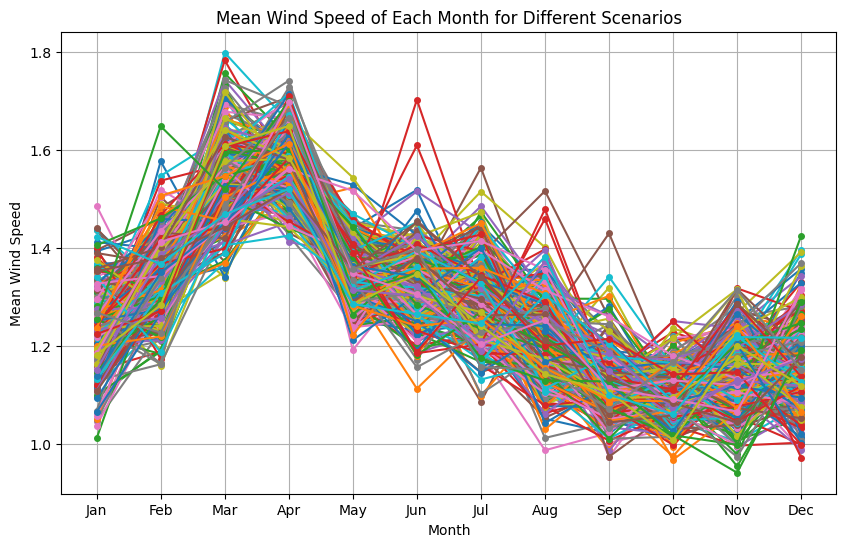

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# Get the current directory
current_directory = os.getcwd()

# Get all CSV files in the current directory
scenario_files = [file for file in os.listdir(current_directory) if file.endswith('.csv')]

# Create a date range for the entire year
start_date = pd.Timestamp('2023-01-01')
end_date = pd.Timestamp('2023-12-31 23:00:00')
dates = pd.date_range(start=start_date, end=end_date, freq='H')

# Create an empty DataFrame to store the monthly means for each scenario
df_monthly_means = pd.DataFrame(index=range(1, 13))

# Loop through each scenario file
for scenario_file in scenario_files:
    # Read the CSV file
    df_scenario = pd.read_csv(os.path.join(current_directory, scenario_file), header=None, names=['wind_speed'])

    # Set the datetime index for the DataFrame
    df_scenario.index = dates

    # Calculate the mean wind speed for each month
    monthly_means = df_scenario.groupby(df_scenario.index.month).mean()

    # Store the monthly means in the DataFrame
    df_monthly_means[scenario_file] = monthly_means.values

# Plot the mean wind speed of each month for all scenarios
plt.figure(figsize=(10, 6))
for scenario_file in scenario_files:
    plt.plot(range(1, 13), df_monthly_means[scenario_file], marker='o', linestyle='-', markersize=4, label=scenario_file)

plt.xlabel('Month')
plt.ylabel('Mean Wind Speed')
plt.title('Mean Wind Speed of Each Month for Different Scenarios')
plt.xticks(range(1, 13), calendar.month_abbr[1:13])
plt.grid(True)
plt.show()



C:\Users\Alex\AppData\Local\Temp\ipykernel_34492\1046325733.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_means[scenario_file] = monthly_means.values
C:\Users\Alex\AppData\Local\Temp\ipykernel_34492\1046325733.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_means[scenario_file] = monthly_means.values
C:\Users\Alex\AppData\Local\Temp\ipykernel_34492\1046325733.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

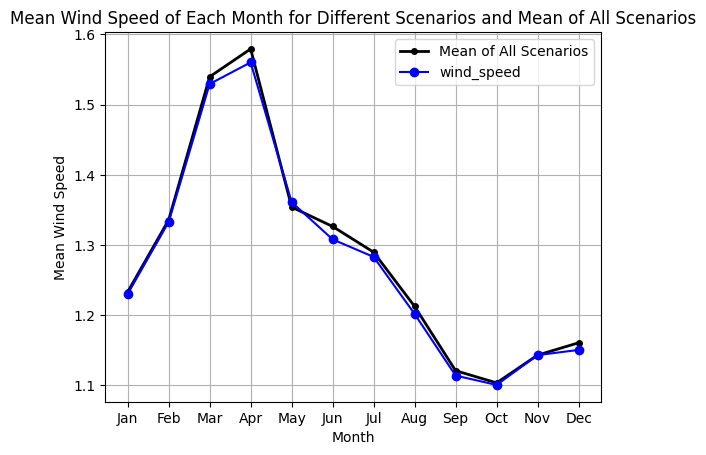

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# Get the current directory
current_directory = os.getcwd()

# Get all CSV files in the current directory
scenario_files = [file for file in os.listdir(current_directory) if file.endswith('.csv')]

# Create a date range for the entire year
start_date = pd.Timestamp('2023-01-01')
end_date = pd.Timestamp('2023-12-31 23:00:00')
dates = pd.date_range(start=start_date, end=end_date, freq='H')

# Create an empty DataFrame to store the monthly means for each scenario
df_monthly_means = pd.DataFrame(index=range(1, 13))

# Loop through each scenario file

for scenario_file in scenario_files:
    # Read the CSV file
    df_scenario = pd.read_csv(os.path.join(current_directory, scenario_file), header=None, names=['wind_speed'])


    # Set the datetime index for the DataFrame
    df_scenario.index = dates

    # Calculate the mean wind speed for each month
    monthly_means = df_scenario.groupby(df_scenario.index.month).mean()

    # Store the monthly means in the DataFrame
    df_monthly_means[scenario_file] = monthly_means.values

# Calculate the mean of all scenario series
df_monthly_means['Mean of All Scenarios'] = df_monthly_means.mean(axis=1)
# Calculate the mean wind speed for each month
monthly_mean = df.groupby(df.index.month)['wind_speed'].mean()

plt.plot(range(1, 13), df_monthly_means['Mean of All Scenarios'], marker='o', linestyle='-', markersize=4, label='Mean of All Scenarios', color='black', linewidth=2)
monthly_mean.plot(marker='o', color='blue')

plt.xlabel('Month')
plt.ylabel('Mean Wind Speed')
plt.title('Mean Wind Speed of Each Month for Different Scenarios and Mean of All Scenarios')
plt.xticks(range(1, 13), calendar.month_abbr[1:13])
plt.grid(True)
plt.legend()
plt.show()

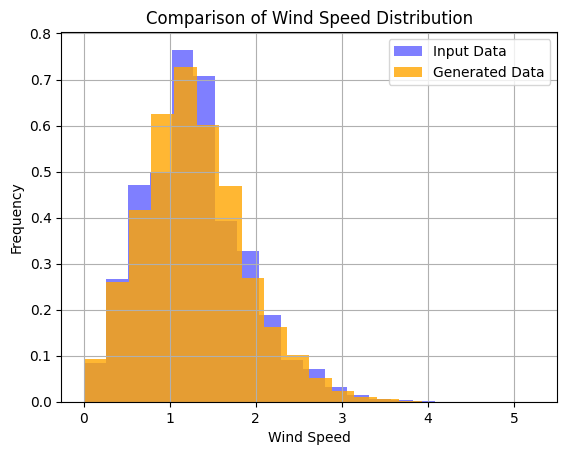

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Get the current directory
current_directory = os.getcwd()

# Get all CSV files in the current directory
scenario_files = [file for file in os.listdir(current_directory) if file.endswith('.csv')]

# Create an empty DataFrame to store the wind speed data
all_wind_speeds = []

# Loop through each scenario file
for scenario_file in scenario_files:
    # Read the CSV file
    df_scenario = pd.read_csv(os.path.join(current_directory, scenario_file), header=None, names=['wind_speed'])
    
    # Append the wind speed values to the list
    all_wind_speeds.extend(df_scenario['wind_speed'].values)


# Plotting the histograms
plt.hist(df['wind_speed'], bins=20, alpha=0.5, label='Input Data', color='blue', density=True)
plt.hist(all_wind_speeds, bins=20, alpha=0.8, label='Generated Data', color='orange', density=True)

plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.title('Comparison of Wind Speed Distribution')
plt.legend()
plt.grid(True)
plt.show()


ValueError: `bins` must be 1d, when an array

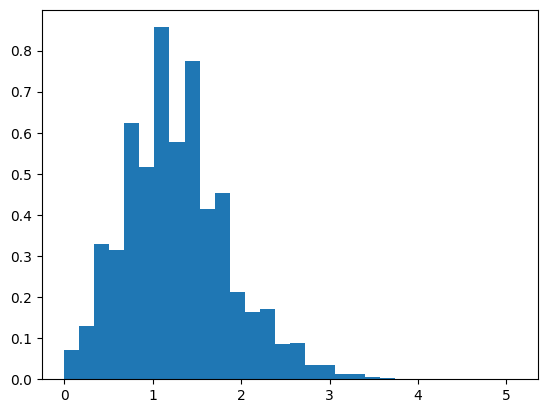

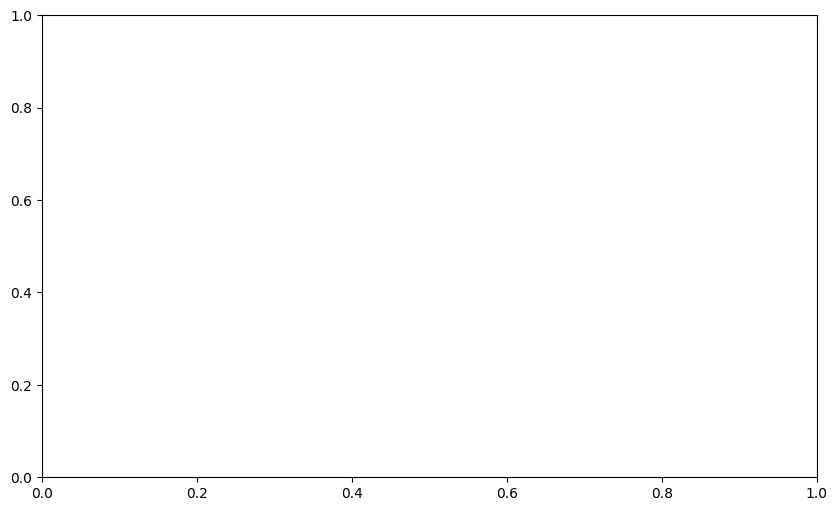